# Exercise 4b - Image Morphology

The purpose of this exercise is to implement, test and validate different approaches to binary image morphological operations.

# Learning Objectives

After completing this exercise, the student should be able to do the following:

1. Define a *structuring element* (also called a *footprint*) using the `disk` function from the `skimage.morphology` package.
2. Perform the morphological operations: *erosion*, *dilation*, *opening* and *closing* on binary images.
3. Compute the outlines seen in a binary image.
4. Use morphological operations to remove holes in objects.
5. Use morphological operations to separate binary objects.
6. Select appropriate footprints based on image properties and object appearance.
7. Combine morphological operations to clean and separate objects.

# Installing Python packages

In this exercise, we will be using [scikit-image](https://scikit-image.org/). You should have this library installed, else instructions can be found in the previous exercises.

We will use the virtual environment from the previous exercise (`course02503`). 

# Exercise data and material

The data and material needed for this exercise can be found here:
(https://github.com/RasmusRPaulsen/DTUImageAnalysis/blob/main/exercises/ex4b-ImageMorphology/data/)

# Image Morphology in Python 

scikit-image contain a variety of [morphological operations](https://scikit-image.org/docs/stable/api/skimage.morphology.html). In this exercise we will explore the use of some of these operations on binary image.

Start by importing some function:

In [1]:
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk 

and define a convenience function to show two images side by side:

In [ ]:
import matplotlib.pyplot as plt 

# From https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    plt.show()


## Image morphology on a single object

An image, **lego_5.png** of a lego brick can be used to test some of the basic functions. 

### Exercise 1

We will start by computing a binary image from the lego image:

- Read the image into **im_org**.
- Convert the image to gray scale. 
- Find a threshold using *Otsu's method*.
- Apply the treshold and generate a binary image **bin_img**.
- Visualize the image using `plot_comparison(im_org, bin_img, 'Binary image')`

As ncan be seen, the lego brick is not *segmented* perfectly. There are holes in the segmentation. Let us see if what we can do.


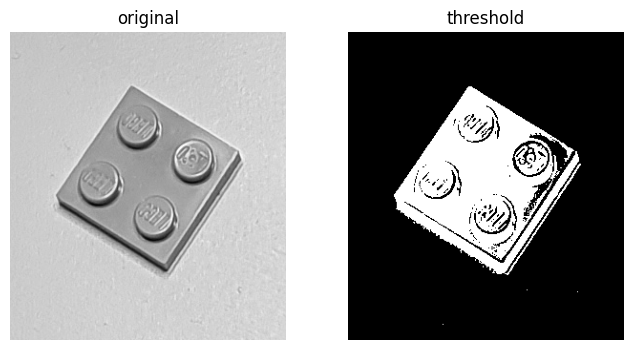

In [ ]:
from skimage import io, color
from skimage.filters import threshold_otsu
im_org = color.rgb2gray(io.imread("../data/lego_5.png"))
theta = threshold_otsu(im_org)
mask = im_org<theta #let's make reverse threshold, we want the lego to be foreground
plot_comparison(im_org,mask,"threshold")



### Exercise 2

We will start by creating a *structuring element*. In scikit-image they are called *footprint*. A disk shaped footprint can be created by:

The morphological operation **erosion** can remove small objects, separate objects and make objects smaller. Try it on the binary lego image:

[[0 0 0 1 0 0 0]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [1 1 1 1 1 1 1]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [0 0 0 1 0 0 0]]


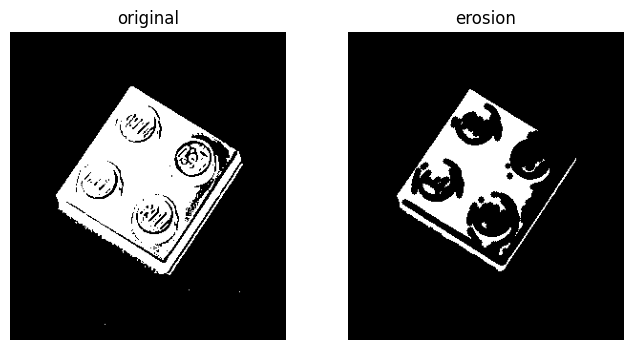

In [21]:
footprint = disk(3)
# Check the size and shape of the structuring element
print(footprint)
eroded = erosion(mask, footprint)
plot_comparison(mask, eroded, 'erosion') #it erodes the white, i.e. highlights

Experiement with different sizes of the footprint and observe the results.

### Exercise 3

The morphological operation **dilation** makes objects larger, closes holes and connects objects. Try it on the binary lego image:

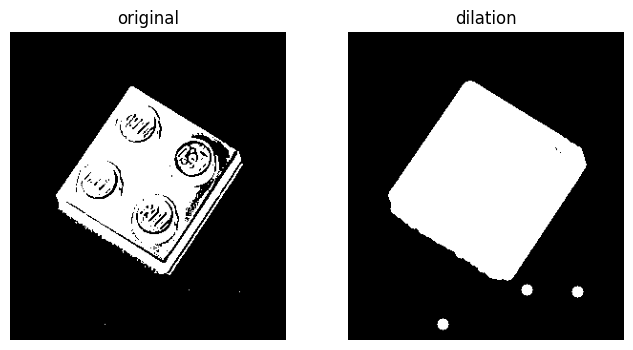

In [32]:
footprint = disk(6)
dilated = dilation(mask, footprint)
plot_comparison(mask, dilated, 'dilation')

Experiement with different sizes of the footprint and observe the results.

### Exercise 4

The morphological operation **opening** removes small objects without changing the size of the remaining objects. Try it on the binary lego image:

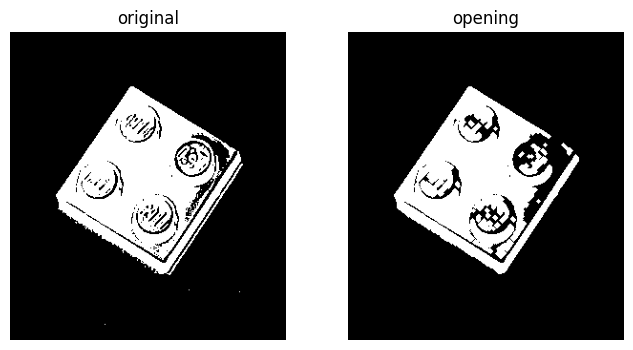

In [38]:
footprint = disk(2)
opened = opening(mask, footprint)
plot_comparison(mask, opened, 'opening')

Experiement with different sizes of the footprint and observe the results.

### Exercise 5

The morphological operation **closing** closes holes in objects without changing the size of the remaining objects. Try it on the binary lego image:

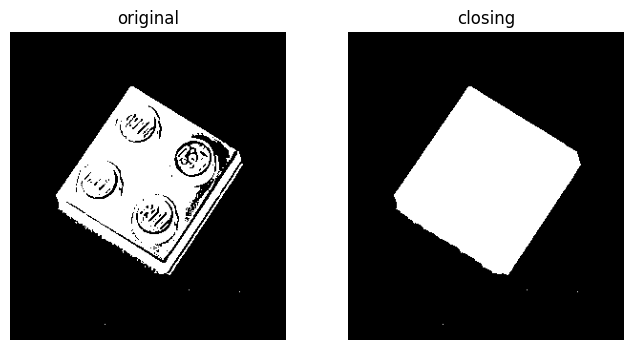

In [43]:
footprint = disk(8)
closed = closing(mask, footprint)
plot_comparison(mask, closed, 'closing')

Experiement with different sizes of the footprint and observe the results.

## Object outline

It can be useful to compute the outline of an object both to measure the perimeter but also to see if it contains holes or other types of noise. Start by defining an outline function:

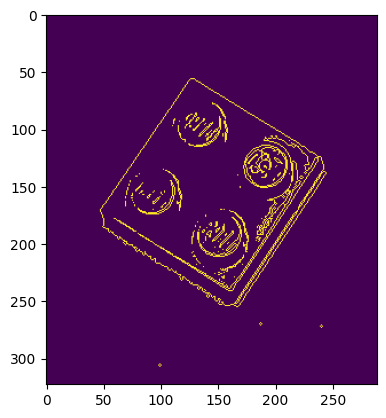

In [47]:
import numpy as np 

def compute_outline(bin_img):
    """
    Computes the outline of a binary image
    """
    footprint = disk(1)
    dilated = dilation(bin_img, footprint)
    plt.imshow(dilated)
    outline = np.logical_xor(dilated, bin_img)
    return outline

outline = compute_outline(mask)
plt.imshow(outline)

### Exercise 6

Compute the outline of the binary image of the lego brick. What do you observe?


Small floaters, and obviously some noise from highlights. 


### Exercise 7

Try the following:

- Do an *opening* with a disk of size 1 on the binary lego image.
- Do a *closing* with a disk of size 15 on the result of the opening.
- Compute the outline and visualize it.

What do you observe and why does the result look like that?


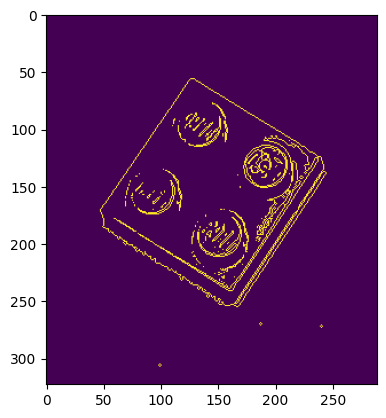

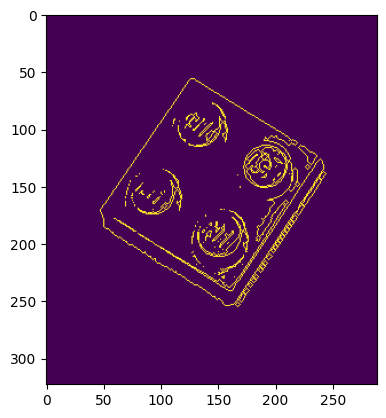

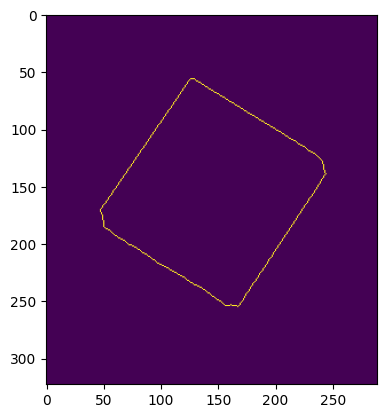

In [ ]:
plt.figure()
plt.imshow(compute_outline(mask))

element = disk(1)
out = opening(mask,element) #kill floaters
plt.figure()
plt.imshow(compute_outline(out))

element = disk(15)
out = closing(out,element) #kill holes inside 
plt.figure()
plt.imshow(compute_outline(out))

# basically we do (erosion -> dilation, which removes holes but also reduces size a lot and then dilation increases size back to org). The erosion kills the floaters present.
# then we do closing (dilation -> erosion) which is to fix the size issue and additionally fill inside holes. 







## Morphology on multiple objects

Let us try to do some analysis on images with multiple objects.

### Exercise 8

Start by:
- reading the **lego_7.png** image and convert it to gray scale.
- Compute a treshold using *Otsu's method* and apply it to the image.
- Show the binary image together with the original.
- Compute the outline of the binary image and show it with the binary image.

What do you observe?


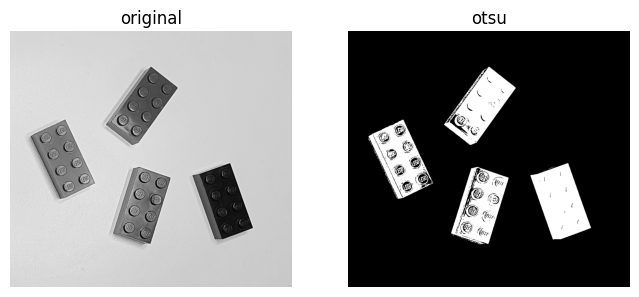

In [63]:
im = color.rgb2gray(io.imread("../data/lego_7.png"))
theta = threshold_otsu(im)
plot_comparison(im, im<theta,"otsu")


### Exercise 9

We would like to find a way so only the outline of the entire brick is computed. So for each lego brick there should only be one closed curve.

Try using the *closing* operations and find out which size of footprint that gives the desired result?




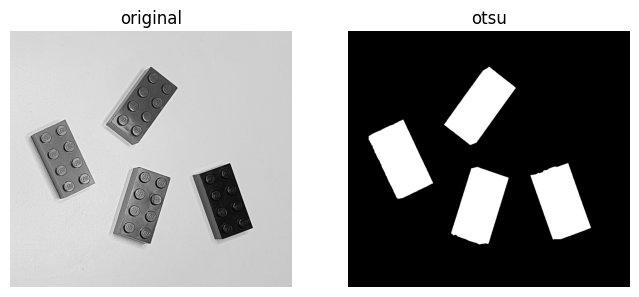

In [67]:
im = color.rgb2gray(io.imread("../data/lego_7.png"))
theta = threshold_otsu(im)
mask = im<theta
SE = disk(8)
morph_mask = closing(mask,SE)
plot_comparison(im, morph_mask,"otsu")



### Exercise 10

Try the above on the **lego_3.png** image. What do you observe?

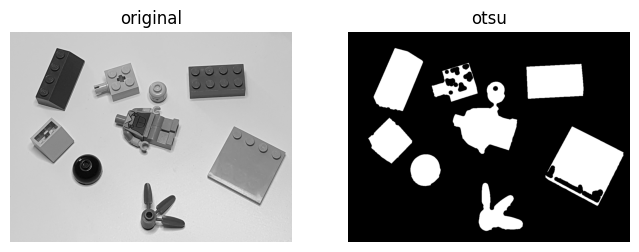

In [73]:
im = color.rgb2gray(io.imread("../data/lego_3.png"))
theta = threshold_otsu(im)
mask = im<theta
#SE = disk(18) <- this fixes it for this image
SE = disk(8)
morph_mask = closing(mask,SE)
plot_comparison(im, morph_mask,"otsu")

Actually translates fairly well to other legos, with a bit of difficulty on strong highlights and the weird brick which has a cross in the middle

## Morphology on multiple connected objects

Morphology is a strong tool that can be used to clean images and separate connected objects. In image **lego_9.png** some lego bricks are touching. We would like to see if we can separate them.

### Exercise 11

Start by:
- reading the **lego_9.png** image and convert it to gray scale.
- Compute a treshold using *Otsu's method* and apply it to the image.
- Show the binary image together with the original.
- Compute the outline of the binary image and show it with the binary image.

What do you observe?


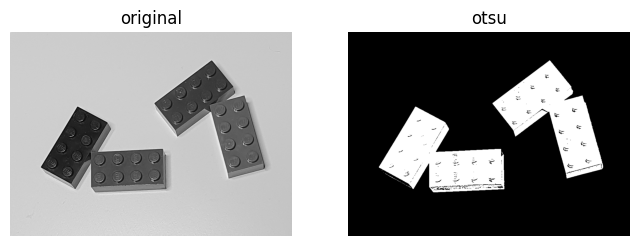

In [76]:

im = color.rgb2gray(io.imread("../data/lego_9.png"))
theta = threshold_otsu(im)
mask = im<theta
plot_comparison(im, mask,"otsu")


We have clear background seperation. So we only need to somehow seperate the objects and remove noise inside



### Exercise 12

Let us start by trying to remove the noise holes inside the lego bricks. Do that with an *closing* and find a good footprint size. Compute the outline and see what you observe?




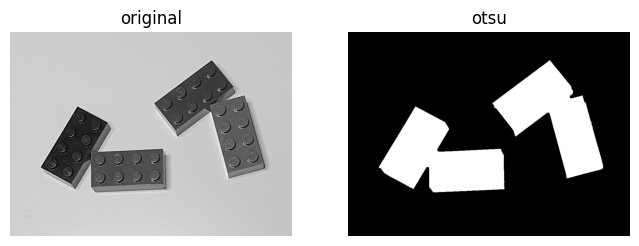

In [92]:
SE = disk(5)
out = closing(mask,SE)
plot_comparison(im, out,"otsu")


### Exercise 13

Now we will try to separate the objects. Try using a *erosion* on the image that you repaired in exercise 12. You should probably use a rather large footprint. How large does it need to be in order to split the objects?


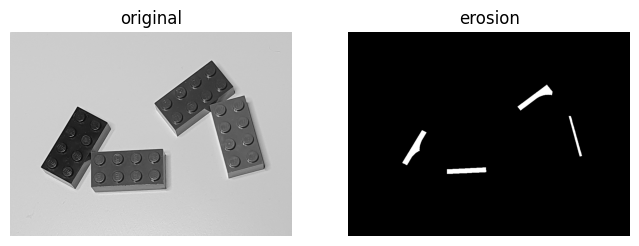

In [ ]:
SE = disk(50)
out_eroded = erosion(out,SE)
plot_comparison(im, out_eroded,"erosion")

### Exercise 14

The objects lost a lot of size in the previous step. Try to use *dilate* to make them larger. How large can you make them before they start touching?




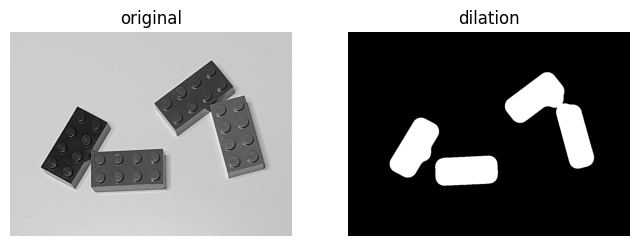

In [104]:
SE = disk(29)
out_dilated = dilation(out_eroded,SE)
plot_comparison(im,out_dilated,"dilation")

## Puzzle piece analysis

We would like to make a program that can help solving puzzles. The first task is to outline each piece. A photo, **puzzle_pieces.png** is provided. 

### Exercise 15

Use the previosly used methods to compute a binary image from the puzzle photo. What do you observe?


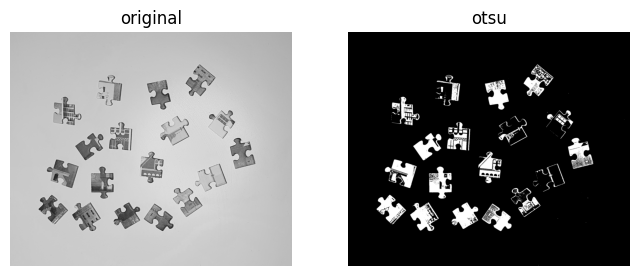

In [108]:
im = color.rgb2gray(io.imread("../data/puzzle_pieces.png"))
theta = threshold_otsu(im)
mask = im<theta
plot_comparison(im,mask,"otsu")


### Exercise 16

Try to use *closing* with a large footprint to clean the binary. Compute the outline. Do we have good outlines for all the pieces?

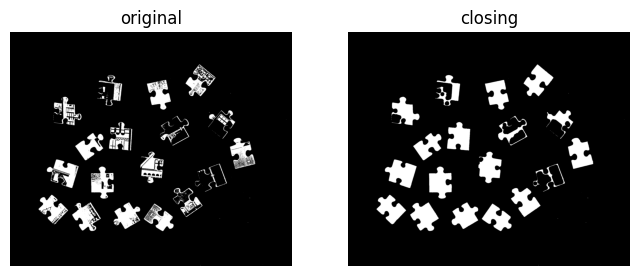

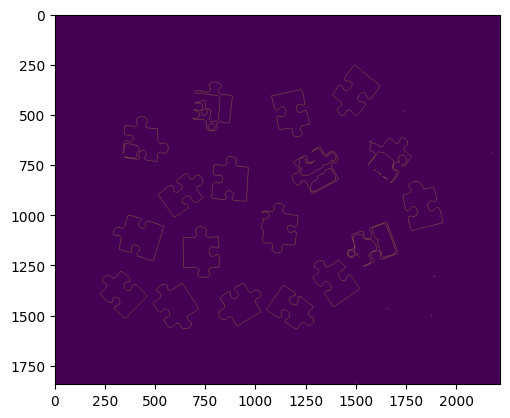

In [112]:
clean = closing(mask,footprint=disk(15))
plot_comparison(mask,clean,"closing")
plt.figure()
plt.imshow(compute_outline(clean))



I think we can fix most of them, but some of them are unfixable using morphological ops, rather take good image instead. We can tune up the filter and close them even more, but then we have the issue that we begin loosing hole information and deforming hole-geometry.  

The conclusion is that you can solve a lot of problems using morphological operations but sometimes it is better to think even more about how to acquire the images. 

## References
- [sci-kit image morphology](https://scikit-image.org/docs/stable/api/skimage.morphology.html)
- [sci-kit morphology examples](https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html)

Time: 37 minutes 